<a href="https://colab.research.google.com/github/S2-K7/Modularity-on-the-Karate-Club-Graph/blob/main/Modularity_on_KarateClubGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DSC 212 : Modularity on the Karate Club Graph**
**Submitted By**: Sankeerth Kathiran, IMS24210

---



In [492]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

### **Loading the karate club graph**

---



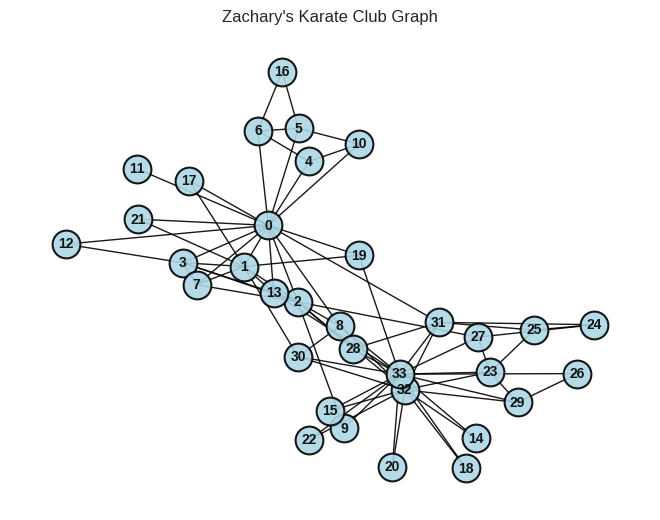

Nodes: 34 
Edges: 78


In [493]:

G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos,
        with_labels=True,
        node_color='lightblue',
        node_size=400,
        font_size=10,
        font_weight='bold',
        edge_color='black',
        width=1,
        edgecolors='black',
        linewidths=1.5,
        alpha=0.9)
plt.title("Zachary's Karate Club Graph")
plt.show()

print("Nodes:", G.number_of_nodes(),"\nEdges:", G.number_of_edges())

### **Computing the restricted modularity graph**


> The modularity objective, modularity matrix B, and spectral bipartition method are based on standard results; see *'Newman (2006), “Modularity and community structure in
networks,” PNAS 103(23):8577–8582*




---



In [494]:
def compute_modularity_matrix(G, nodes):
    node_list = list(nodes)
    k = np.array([G.degree(u) for u in node_list], dtype=float)
    m = G.number_of_edges()

    # Adjacency of subgraph
    A = np.zeros((len(nodes), len(nodes)))
    for i,u in enumerate(node_list):
        for j,v in enumerate(node_list):
            if G.has_edge(u,v):
                A[i,j] = 1.0

    # kk^T/(2m) calculation
    K = np.outer(k, k) / (2*m)

    B = A - K
    return B, node_list



### **Two way spectral split by computing eigen values of B**


---



In [495]:

def leading_eigenpair(B):
    vals, vecs = eigh(B)
    idx = np.argmax(vals)
    return vals[idx], vecs[:, idx]

def spectral_bisection(G, nodes):
    B, node_list = compute_modularity_matrix(G, nodes)
    lam, u = leading_eigenpair(B)

    if lam <= 0:
        return None, None, lam  #

    pos = [node_list[i] for i in range(len(node_list)) if u[i] > 0] #C+
    neg = [node_list[i] for i in range(len(node_list)) if u[i] <= 0] #C-

    return pos, neg, lam


### **Recursive Split to get multiple communities**

---



In [496]:
def recursive_spectral_modularity(G):
    communities = [list(G.nodes())]
    snapshots = []   # This list helps to plot the communities for each iteration
    lambdas = []

    queue = [list(G.nodes())]

    while queue:
        group = queue.pop(0)


        pos, neg, lam = spectral_bisection(G, group)
        lambdas.append(lam)

        if len(group) <= 1 or not pos or not neg:
            continue

        # Replace old group with 2 new ones
        communities.remove(group)
        communities.append(pos)
        communities.append(neg)

        # Store snapshot
        snapshots.append([sorted(c) for c in communities])

        queue.append(pos)
        queue.append(neg)

    return snapshots, lambdas

### **Function to plot the communities**

---



In [497]:
def plot_communities(G, communities, title):
    color_map = {}
    for cid, com in enumerate(communities):
        for n in com:
            color_map[n] = cid

    node_colors = [color_map[n] for n in G.nodes()]

    plt.figure(figsize=(7,6))
    plt.title(title)
    nx.draw(G, pos, with_labels=True, node_color=node_colors,  #Aesthetics for the graph.
            cmap=plt.cm.Paired, node_size=350,
            edgecolors='black',
            linewidths=1.5,
            alpha=0.7)
    plt.show()

### **Visualization**

---




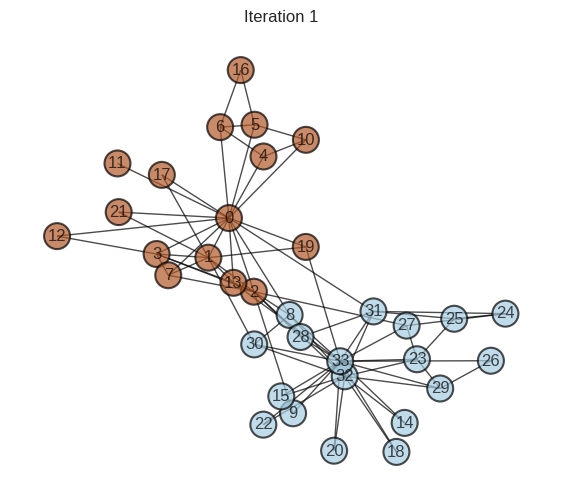

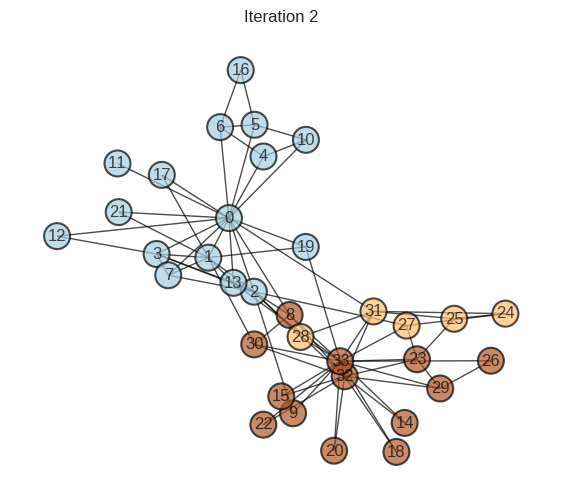

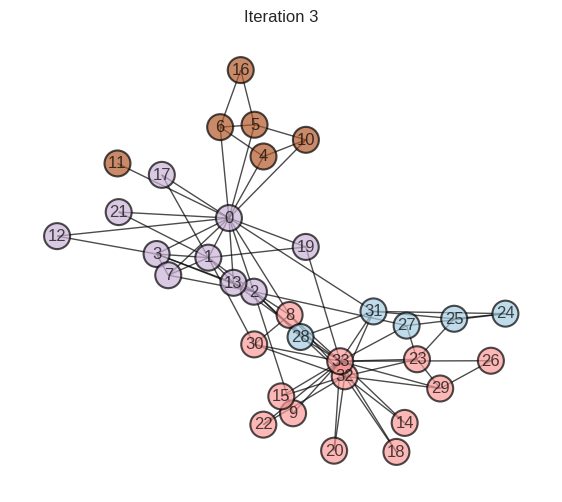

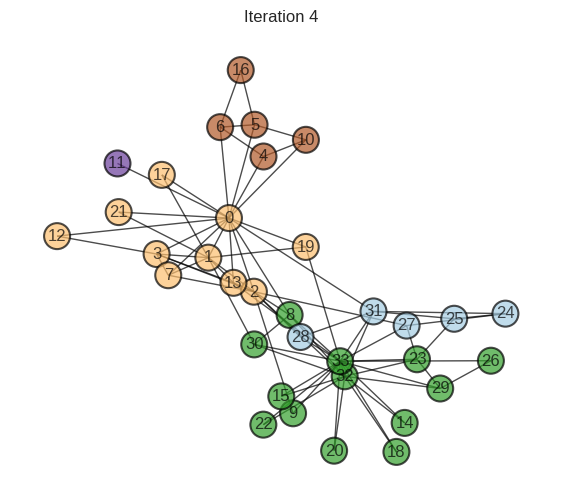



Final Communities:
Community 1 = [24, 25, 27, 28, 31]
Community 2 = [8, 9, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33]
Community 3 = [0, 1, 2, 3, 7, 12, 13, 17, 19, 21]
Community 4 = [11]
Community 5 = [4, 5, 6, 10, 16]


In [498]:
snapshots, lambdas = recursive_spectral_modularity(G)


for i, com in enumerate(snapshots):
    plot_communities(G, com, f"Iteration {i+1}")



print("\n\nFinal Communities:")
if snapshots:
    final_communities = snapshots[-1]
    for i, community in enumerate(final_communities):
        print(f"Community {i+1} = {community}")


### **Node Metrics computation**


---



In [499]:
metric_history = {} #After each iteration, store the metric values in a dictionary keyed by iteration number.

#This is for iter0, the orgianl graph
def compute_global_metrics(G):
    return {
        "degree": nx.degree_centrality(G),
        "betweenness": nx.betweenness_centrality(G),
        "closeness": nx.closeness_centrality(G),
        "clustering": nx.clustering(G),
    }
#This is for iter1-4 ...plotting it for each communities
def compute_community_metrics(G, communities):
    current_iter_metrics = {
        "degree": {},
        "betweenness": {},
        "closeness": {},
        "clustering": {},
    }
    for community in communities:
        subgraph = G.subgraph(community)

        if subgraph.number_of_nodes() > 1:
            sub_degree = nx.degree_centrality(subgraph)
            sub_betweenness = nx.betweenness_centrality(subgraph)
            sub_closeness = nx.closeness_centrality(subgraph)
            sub_clustering = nx.clustering(subgraph)
        else:
            sub_degree = {node: 0 for node in community}
            sub_betweenness = {node: 0 for node in community}
            sub_closeness = {node: 0 for node in community}
            sub_clustering = {node: 0 for node in community}

        for node in community:
            current_iter_metrics["degree"][node] = sub_degree.get(node, 0)
            current_iter_metrics["betweenness"][node] = sub_betweenness.get(node, 0)
            current_iter_metrics["closeness"][node] = sub_closeness.get(node, 0)
            current_iter_metrics["clustering"][node] = sub_clustering.get(node, 0)
    return current_iter_metrics

# For iter0
metric_history[0] = compute_global_metrics(G)

# for iter1-4
for i, com_list in enumerate(snapshots):
    metric_history[i + 1] = compute_community_metrics(G, com_list)

### **Plotting the node metrics graph**

--------




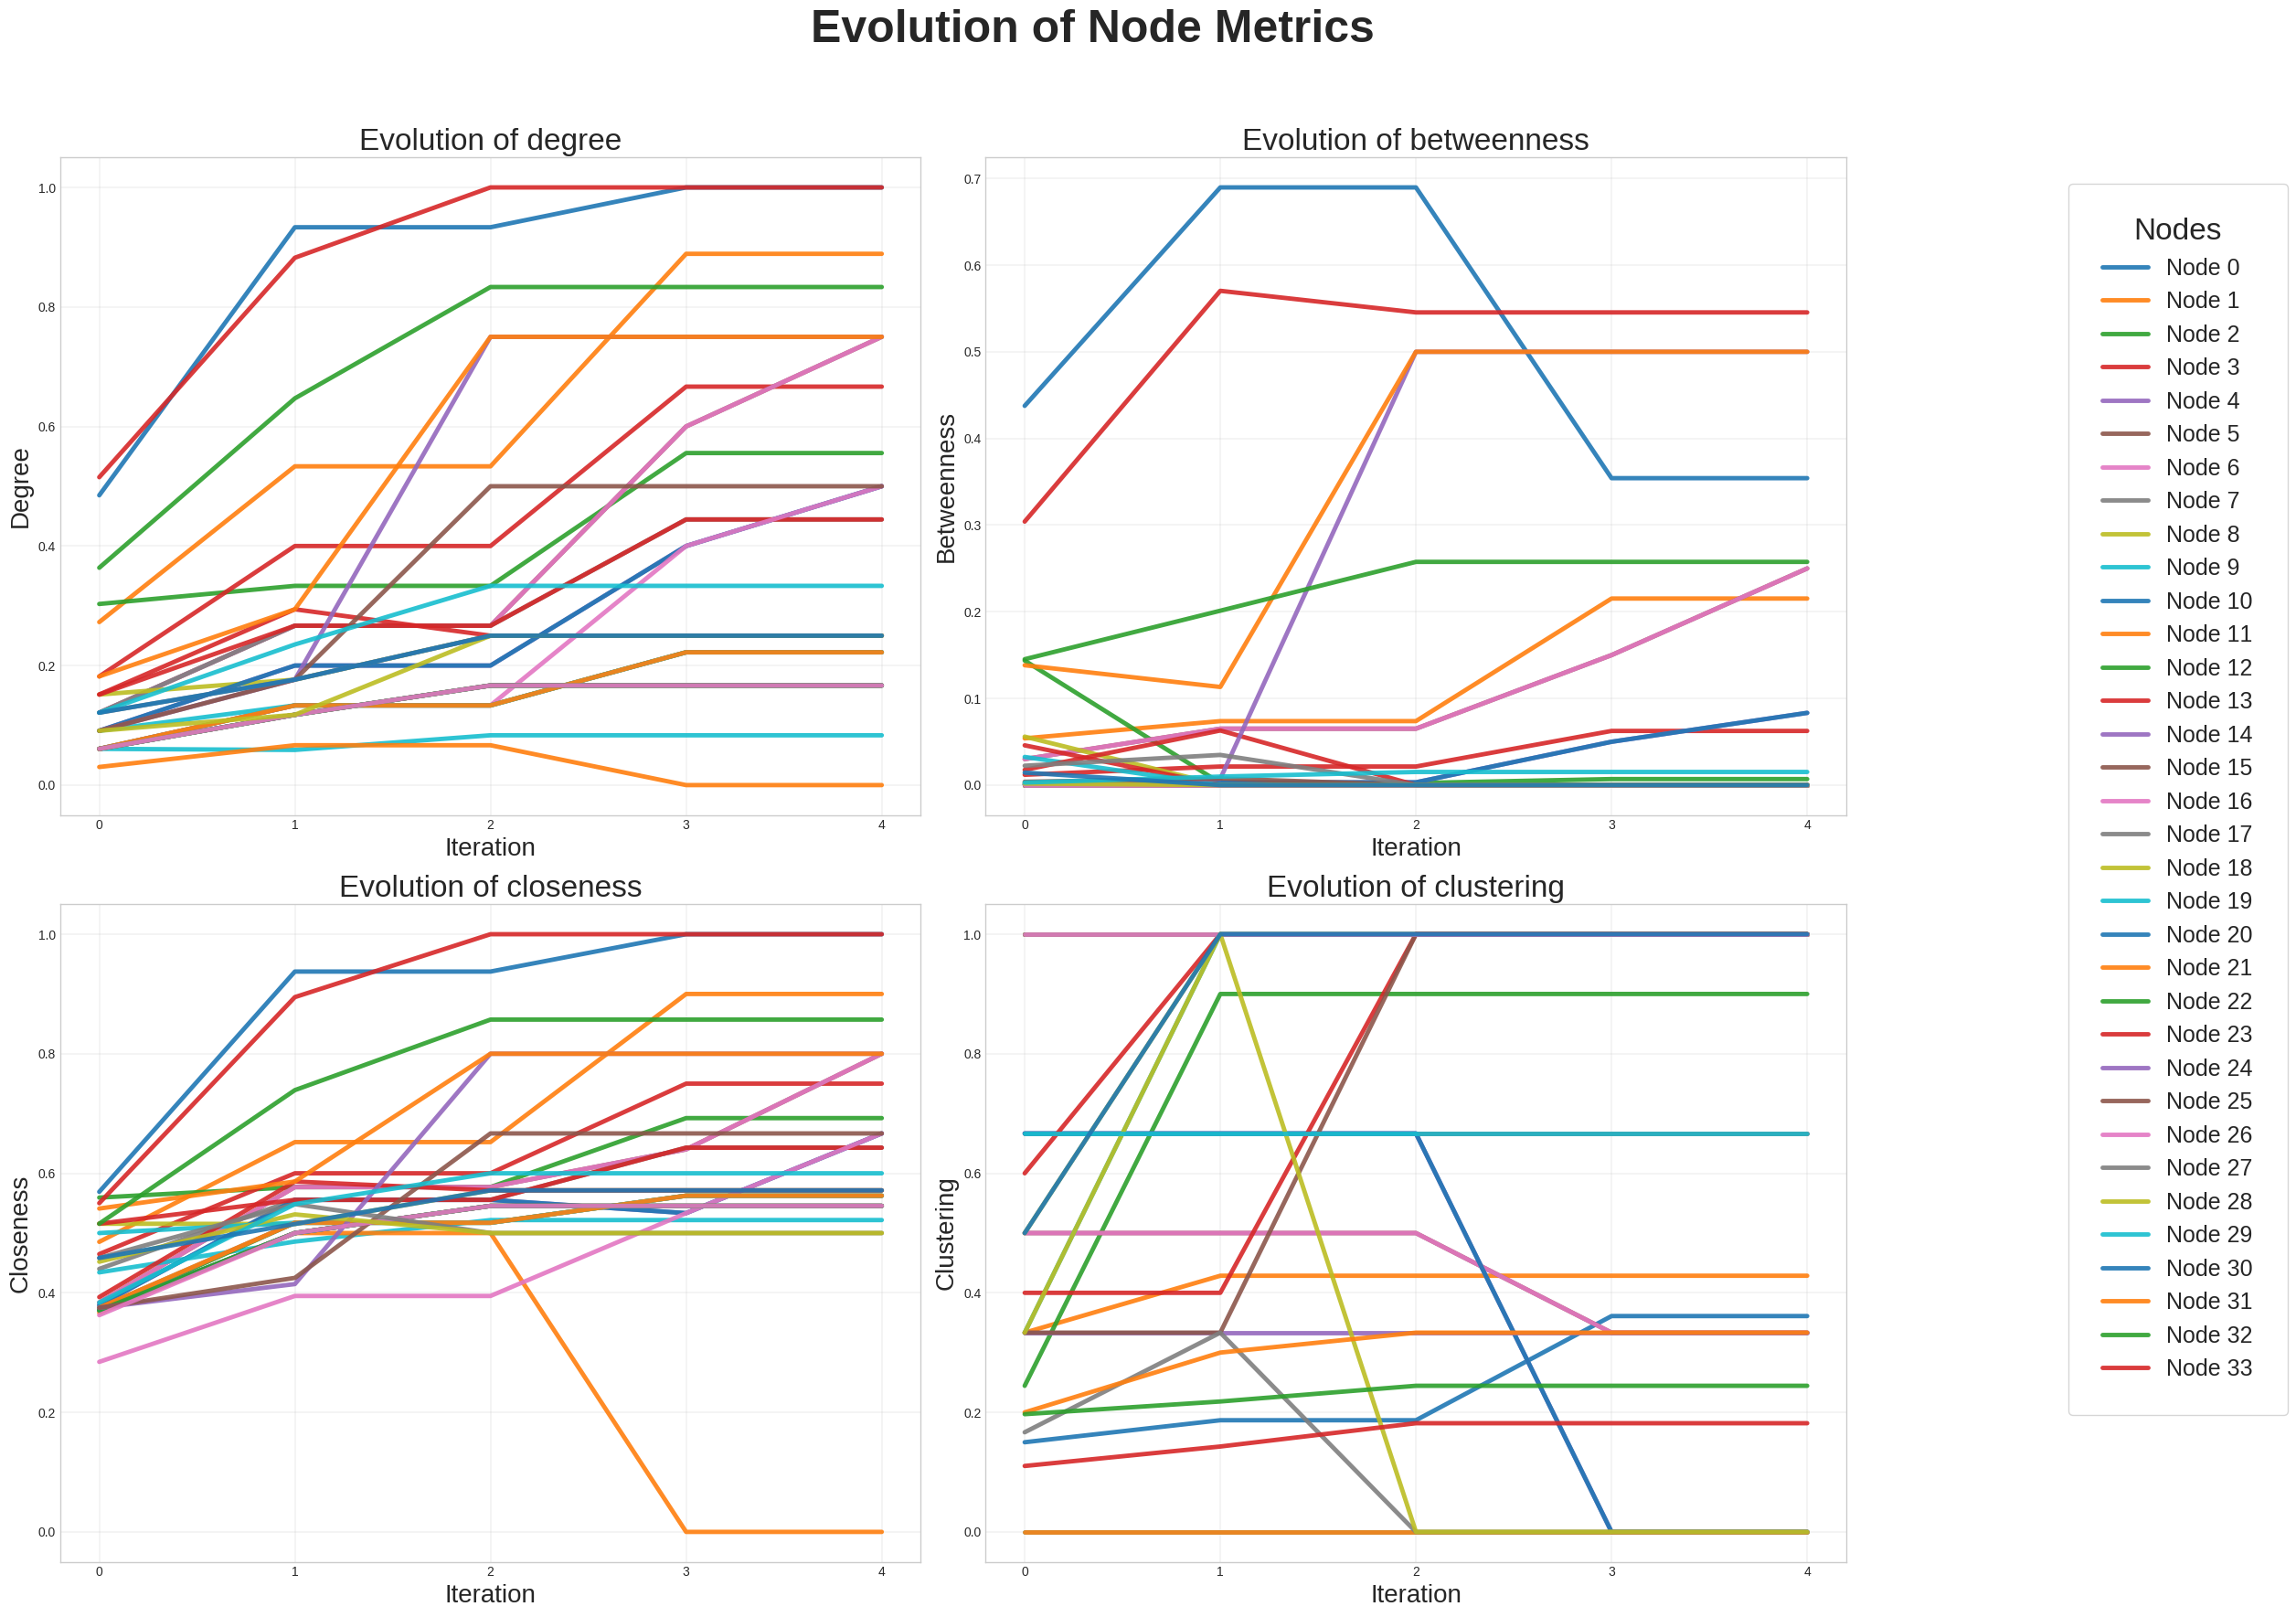

In [500]:
nodes = sorted(G.nodes())
iters = range(len(metric_history))

metrics_to_plot = ["degree", "betweenness", "closeness", "clustering"]

fig, axes = plt.subplots(2, 2, figsize=(24, 18))
axes = axes.flatten()

all_handles = []
all_labels = []

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    ax.set_title(f"Evolution of {metric}", fontsize=24)

    current_handles = []
    current_labels = []

    for n in nodes:
        values = [metric_history[j][metric][n] for j in iters]
        line, = ax.plot(
            iters, values,
            linewidth=3.5,
            alpha=0.9,
        )

        if i == 0:
            current_handles.append(line)
            current_labels.append(f"Node {n}")

    ax.set_xlabel("Iteration", fontsize=20)
    ax.set_ylabel(metric.capitalize(), fontsize=20)
    ax.set_xticks(iters)
    ax.grid(True, alpha=0.25, linewidth=1.2)

    if i == 0:
        all_handles = current_handles
        all_labels = current_labels

fig.legend(
    all_handles,
    all_labels,
    loc='center right',
    bbox_to_anchor=(1.05, 0.5),
    title="Nodes",
    title_fontsize=24,
    fontsize=18,
    markerscale=3,
    frameon=True,
    borderpad=1.5,
)

fig.suptitle("Evolution of Node Metrics", fontsize=36, fontweight='bold')

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()


### **Discussion**
Which nodes consistently remain central across splits, and how
community structure influences these metrics?




*Answer:*


**Nodes 0, 32, and 33 (especially 0 and 33) consistently remain central in the Karate Club graph across community splits for degree, betweenness, and closeness. Node 31 is consistently central for betweenness**

*   **Degree Centrality**: Nodes **`0, 32, 33`** consistently maintain a high degree centrality.

*   **Betweenness Centrality**: Nodes **`0, 31, 32, 33`** consistently exhibit high betweenness centrality.

*   **Closeness Centrality**: Nodes **`0, 33`** consistently show high closeness centrality.

*   **Clustering Coefficient**: No nodes were consistently found in the top 5 for clustering coefficient across all iterations. Clustering coeffecient is defined as
> Fraction of a node’s neighbors that are also connected to each other. High clustering
indicates that i is embedded in a tightly-knit group (a local community or clique).
    
     By using the definition, The “tight-knit group” around each node keeps changing, so their clustering score rises and falls unpredictably because when the graph gets splitted into smaller communities, each nodes's neighbourhood also changes at each iteration.


-----------

**Communities structure influences the metrics in the following ways**




*   When a node (eg: **`0,32,33`**) stays inside a big, well-connected community, its degree, betweenness, and closeness centrality stay high. Even though the whole graph gets split into smaller parts, these nodes are still important inside their subgraph.

*   When a node is a bridging node like **`31`**, it keeps its betweenness centrality even we split the communities to make it smaller

*  If a node ends up alone like **`11`**, its centrality metrics because zero or undefined.







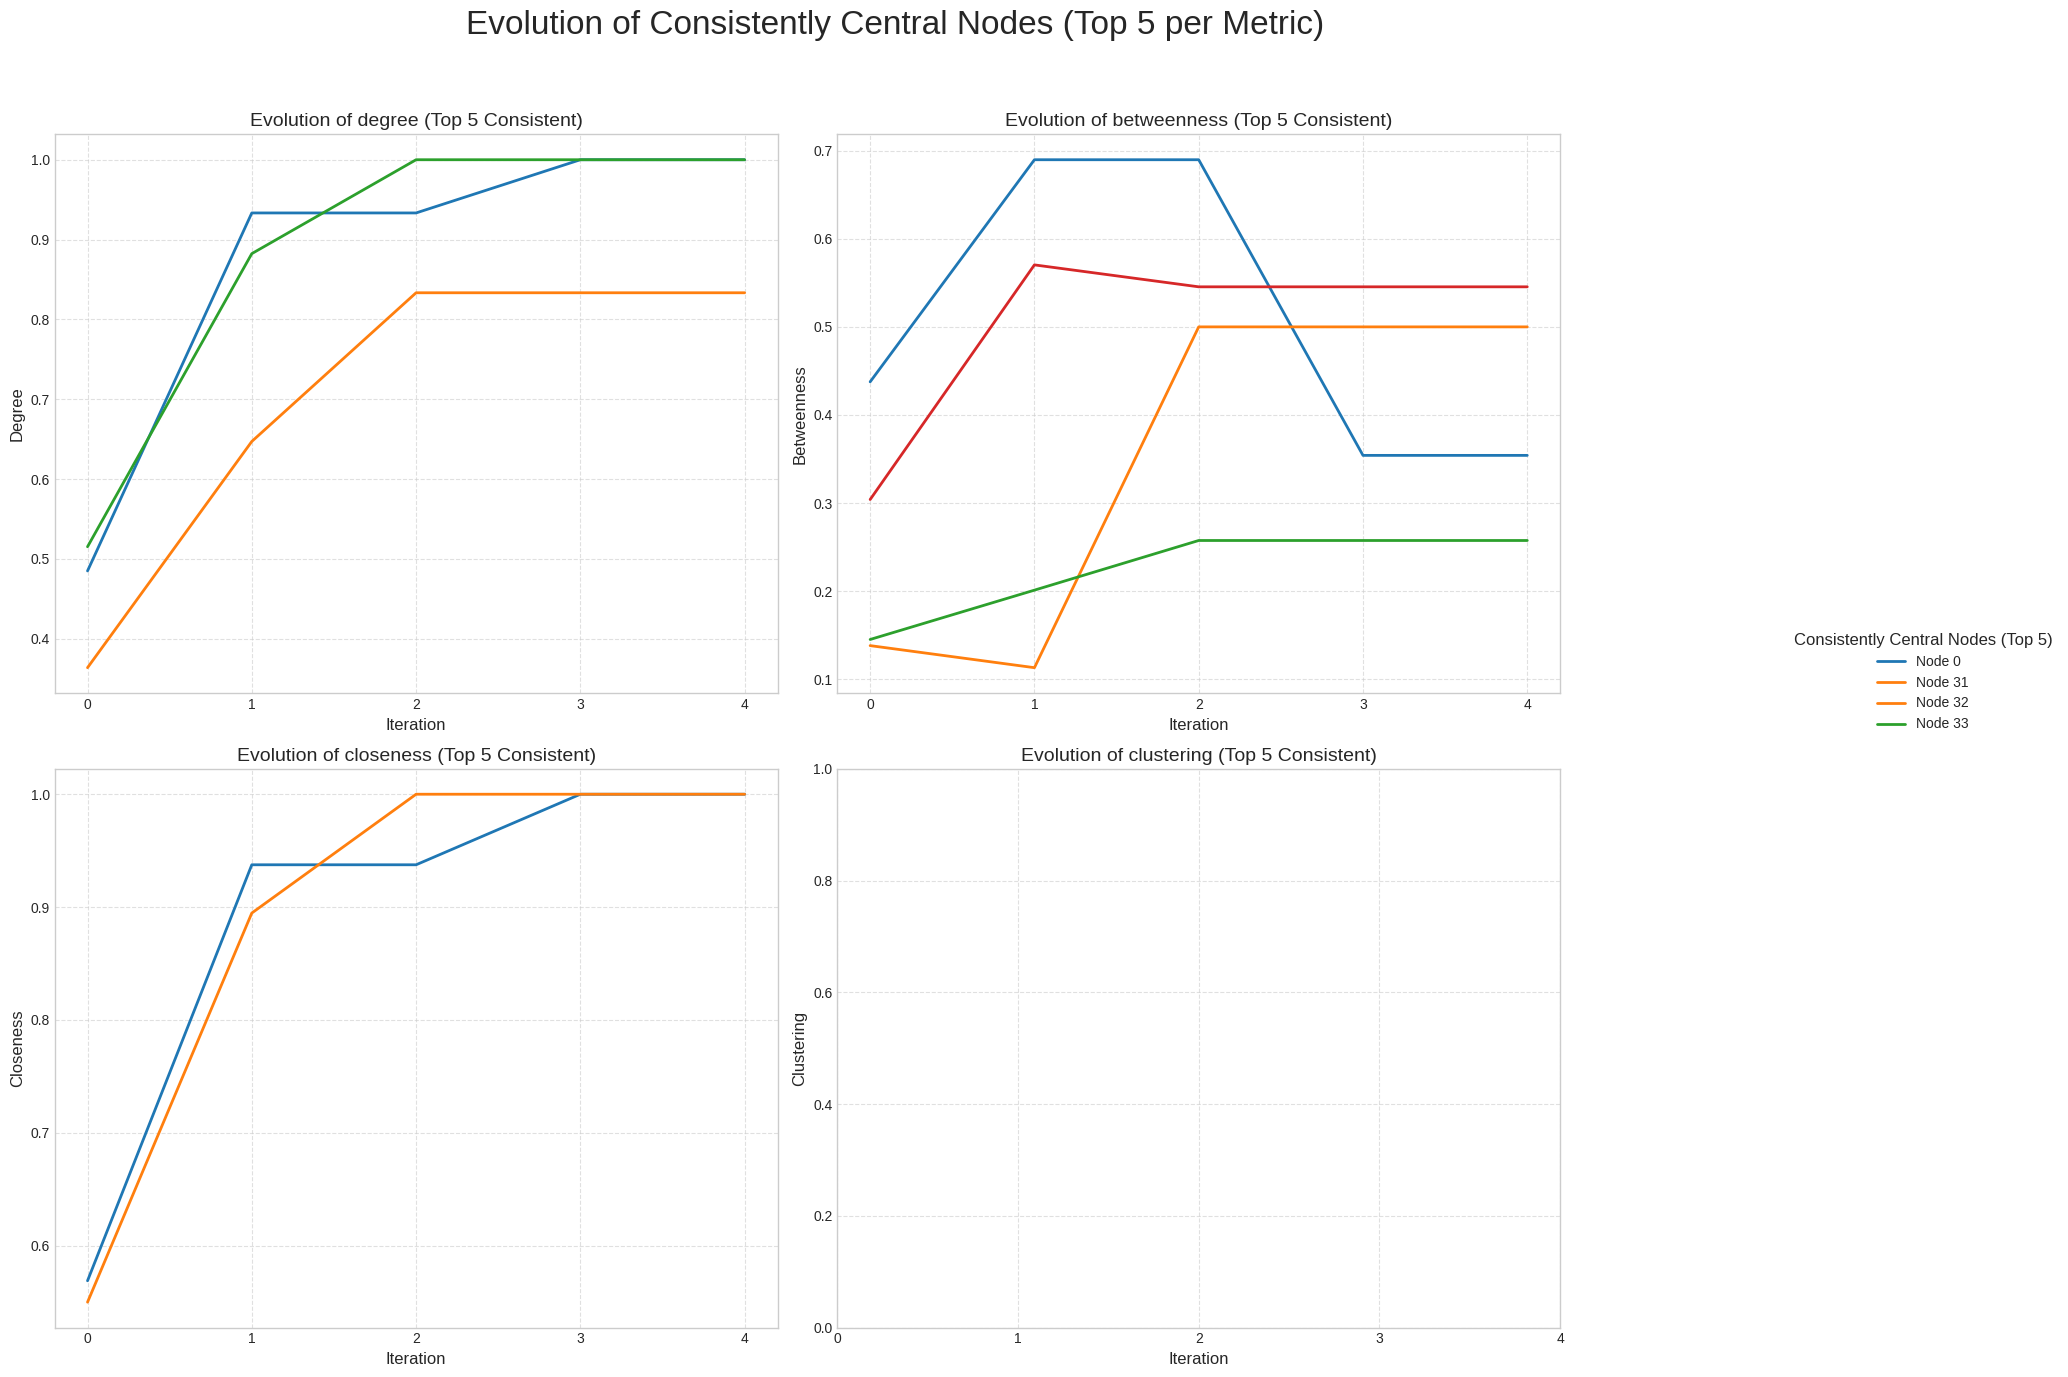

In [501]:
#fully A.I generated part below...I wanted to quickly visualize the top 5 parts for writting the discussion because
# the above plot where all node metrics was plotted is too messy to compare all nodes based on metrices.

top_n = 5

iters = range(len(metric_history))
metrics_to_plot = ["degree", "betweenness", "closeness", "clustering"]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# Store all handles and labels across all subplots to create a unified legend
unified_handles = {}

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    ax.set_title(f"Evolution of {metric} (Top {top_n} Consistent)", fontsize=14)

    # Get the list of consistently central nodes for the current metric
    nodes_to_plot_for_metric = consistently_central_nodes.get(metric, [])

    for n in nodes_to_plot_for_metric:
        values = [metric_history[j][metric][n] for j in iters]
        line, = ax.plot(iters, values, linewidth=2, label=f"Node {n}") # Increased linewidth for visibility

        # Store handle for unified legend, only once per node
        if n not in unified_handles:
            unified_handles[n] = line

    ax.set_xlabel("Iteration", fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_xticks(iters)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.6) # Add a grid for readability

# Create a single legend for the entire figure, using unique nodes
handles = [unified_handles[n] for n in sorted(unified_handles.keys())]
labels = [f"Node {n}" for n in sorted(unified_handles.keys())]

fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.5),
           title=f"Consistently Central Nodes (Top {top_n})", fontsize=10, title_fontsize=12)
fig.suptitle(f"Evolution of Consistently Central Nodes (Top {top_n} per Metric)", fontsize=24)
plt.tight_layout(rect=[0, 0, 0.88, 0.95]) # Adjust layout to make space for the legend and suptitle
plt.show()






---


                                                                              End of Assignment

                                                                  Submitted by Sankeerth Kathiran,IMS24210

                                                              Used the NetworkX documentation and AI tools whenever
                                                                 my syntax refused to work and for code cleanup.